# 3. Machine Learning: Predicting BOTZ ETF Returns

**Research context:** EDA and HT established that:
- Raw correlation (r ≈ 0.49) between paper counts and ETF price is spurious.
- After stationarising, the linear relationship collapses to r ≈ −0.02.
- A weak 3-day Granger precedence exists (p < 0.05) but explains < 0.2% of return variance.

This notebook asks a harder question: **can non-linear ML models extract a predictive signal that simple correlation analysis misses?**

### Problem framing
| Task | Target | Metric |
|------|--------|--------|
| Regression | `daily_return` (continuous) | RMSE, R² |
| Classification | `direction` (Up/Down) | Accuracy, Macro F1 |
| Clustering | — (unsupervised) | Silhouette, ARI |

### Models tested
Regression: Linear Regression · Random Forest · XGBoost · SVR · LSTM  
Classification: Logistic Regression · Random Forest  
Clustering: K-Means

### Key methodological safeguards
- **Chronological 80/20 split** — no future data leaks into training.
- **TimeSeriesSplit CV** — all hyperparameter searches respect temporal order.
- **Scaler fitted on train only** — `transform()` applied separately to test set.
- **Consistent tuning across all models** — ensures fair comparison.

## 0. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, adjusted_rand_score, silhouette_score
)
from xgboost import XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

# ── Shared constants ──────────────────────────────────────
RANDOM_STATE = 42
CV_SPLITS    = 5
TRAIN_RATIO  = 0.80

# ── Colour palette ────────────────────────────────────────
COLORS = {
    'actual'  : '#1f77b4',
    'pred_lr' : '#d62728',
    'pred_rf' : '#2ca02c',
    'pred_xgb': '#ff7f0e',
    'pred_svr': '#9467bd',
    'pred_lstm': '#e377c2',
    'neutral' : '#7f7f7f',
}

tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
print('Setup complete.')

Setup complete.


## 1. Data Loading & Feature Engineering

### Feature design rationale

Every feature is motivated by a specific hypothesis:

| Feature | Hypothesis |
|---------|------------|
| `paper_lag_1/3/5` | Granger test found 3-day precedence; these lags test it directly |
| `paper_ma_7/30` | Short vs. long-run publication trend — momentum proxy |
| `paper_momentum` | Acceleration in research output (7d MA minus 30d MA) |
| `log_paper_diff` | Stationary version of paper count (preferred by HT results) |
| `return_lag_1/5` | Price momentum — past return predicts near-future return (autocorrelation) |
| `abs_return_lag1` | Volatility clustering — high-vol days tend to cluster |
| `dow_*` | Day-of-week dummies — arXiv deadline effect (Monday spike) |

In [2]:
df = (
    pd.read_csv('ai_market_master_dataset.csv', parse_dates=['date'])
      .set_index('date')
      .sort_index()
)

# ── Paper-based features ──────────────────────────────────
df['paper_lag_1']    = df['paper_count'].shift(1)
df['paper_lag_3']    = df['paper_count'].shift(3)   # Granger-motivated
df['paper_lag_5']    = df['paper_count'].shift(5)
df['paper_lag_10']   = df['paper_count'].shift(10)
df['paper_ma_7']     = df['paper_count'].rolling(7).mean()
df['paper_ma_30']    = df['paper_count'].rolling(30).mean()
df['paper_momentum'] = df['paper_ma_7'] - df['paper_ma_30']
df['log_paper_diff'] = np.log1p(df['paper_count']).diff()  # stationary version

# ── Return-based features ─────────────────────────────────
df['return_lag_1']    = df['daily_return'].shift(1)
df['return_lag_5']    = df['daily_return'].shift(5)
df['abs_return_lag1'] = df['daily_return'].abs().shift(1)  # volatility proxy

# ── Day-of-week dummies (Mon=0 ... Fri=4) ─────────────────
for d, name in enumerate(['Mon', 'Tue', 'Wed', 'Thu']):
    df[f'dow_{name}'] = (df.index.dayofweek == d).astype(int)

df.dropna(inplace=True)

FEATURES = [
    'paper_count', 'paper_lag_1', 'paper_lag_3', 'paper_lag_5', 'paper_lag_10',
    'paper_ma_7', 'paper_ma_30', 'paper_momentum', 'log_paper_diff',
    'return_lag_1', 'return_lag_5', 'abs_return_lag1',
    'dow_Mon', 'dow_Tue', 'dow_Wed', 'dow_Thu'
]

X = df[FEATURES]
y = df['daily_return']

# ── Chronological split ───────────────────────────────────
split_idx = int(len(df) * TRAIN_RATIO)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ── Classification target ─────────────────────────────────
y_train_cls = (y_train > 0).astype(int)
y_test_cls  = (y_test  > 0).astype(int)

# ── Scaled versions (for SVR, Logistic, LSTM) ─────────────
scaler         = StandardScaler()
X_train_sc     = scaler.fit_transform(X_train)
X_test_sc      = scaler.transform(X_test)

print(f'Total samples   : {len(df):,}')
print(f'Features        : {len(FEATURES)}')
print(f'Train set       : {len(X_train):,}  ({X_train.index.min().date()} → {X_train.index.max().date()})')
print(f'Test set        : {len(X_test):,}   ({X_test.index.min().date()} → {X_test.index.max().date()})')
print(f'Up/Down (test)  : {y_test_cls.sum()} Up / {(y_test_cls==0).sum()} Down  ({y_test_cls.mean()*100:.1f}% / {(1-y_test_cls.mean())*100:.1f}%)')

Total samples   : 1,807
Features        : 16
Train set       : 1,445  (2016-10-25 → 2022-07-22)
Test set        : 362   (2022-07-25 → 2023-12-29)
Up/Down (test)  : 185 Up / 177 Down  (51.1% / 48.9%)


## 2. Feature Correlation with Target

Before training any model, we check each feature's individual Pearson correlation with `daily_return`. This establishes a baseline expectation: **features with near-zero correlation will provide little linear signal**, though non-linear models might still extract structure.

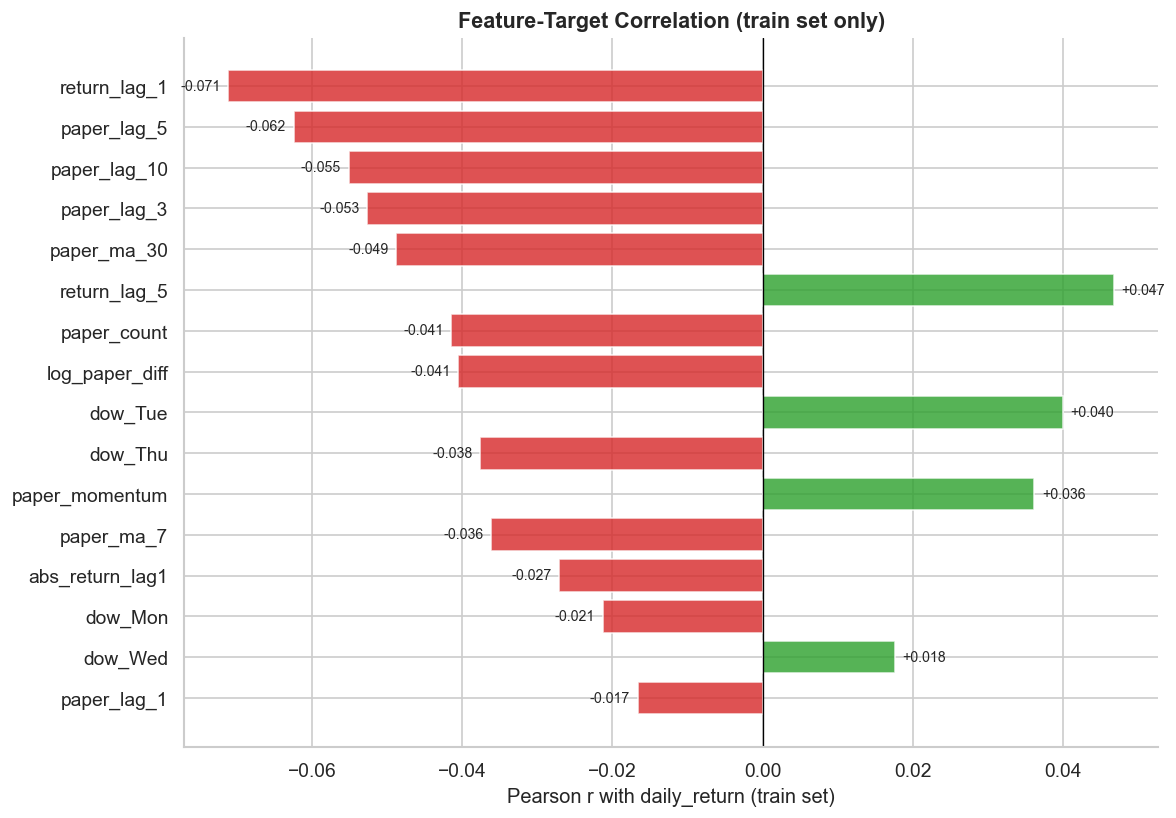


INTERPRETATION
──────────────
• return_lag_1 and return_lag_5 have the highest (though still modest)
  correlations with daily_return. This reflects weak price momentum:
  yesterday's return has marginal predictive power for today's.

• All paper-based features have correlations close to zero. This directly
  confirms the HT finding: on a daily basis, publication volume carries
  virtually no linear signal for next-day returns.

• Day-of-week dummies show near-zero correlations, suggesting no strong
  weekday return seasonality in this ETF.

Implication: any model that performs well on this dataset does so by
capturing non-linear interactions — not by exploiting strong individual
feature signals.



In [3]:
corr_with_target = (
    X_train.assign(daily_return=y_train)
    .corr()['daily_return']
    .drop('daily_return')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [COLORS['pred_rf'] if v > 0 else COLORS['pred_lr']
          for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values,
               color=colors, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with daily_return (train set)', fontsize=12)
ax.set_title('Feature-Target Correlation (train set only)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, corr_with_target.values):
    ax.text(val + (0.001 if val >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8.5)
plt.tight_layout()
plt.show()

print("""
INTERPRETATION
──────────────
• return_lag_1 and return_lag_5 have the highest (though still modest)
  correlations with daily_return. This reflects weak price momentum:
  yesterday's return has marginal predictive power for today's.

• All paper-based features have correlations close to zero. This directly
  confirms the HT finding: on a daily basis, publication volume carries
  virtually no linear signal for next-day returns.

• Day-of-week dummies show near-zero correlations, suggesting no strong
  weekday return seasonality in this ETF.

Implication: any model that performs well on this dataset does so by
capturing non-linear interactions — not by exploiting strong individual
feature signals.
""")

## 3. Regression Models

We train all five regression models and collect results in a shared dictionary for the final comparison. A shared helper function handles evaluation and plotting consistently.

In [4]:
# ── Shared result store ───────────────────────────────────
reg_results  = {}   # {model_name: {'rmse': ..., 'r2': ..., 'y_pred': ...}}
cls_results  = {}

def evaluate_regressor(name: str, y_true, y_pred, color: str, ax_actual=None):
    """Store metrics and plot actual vs predicted on a provided axis."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    reg_results[name] = {'rmse': rmse, 'r2': r2, 'y_pred': y_pred}
    if ax_actual is not None:
        ax_actual.plot(y_test.index, y_true.values,
                       color=COLORS['actual'], alpha=0.5, linewidth=0.8,
                       label='Actual')
        ax_actual.plot(y_test.index, y_pred,
                       color=color, linewidth=1.2, linestyle='--',
                       label=f'{name}  (R²={r2:.3f})')
        ax_actual.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax_actual.set_title(name, fontsize=11, fontweight='bold')
        ax_actual.legend(fontsize=8)
    return rmse, r2

print('Helper functions defined.')

Helper functions defined.


### 3.1 Linear Regression (Baseline)

Linear regression is our interpretable baseline. It assumes that daily returns are a weighted sum of the features — the simplest possible functional form. Its coefficient vector directly shows which features the model relies on.

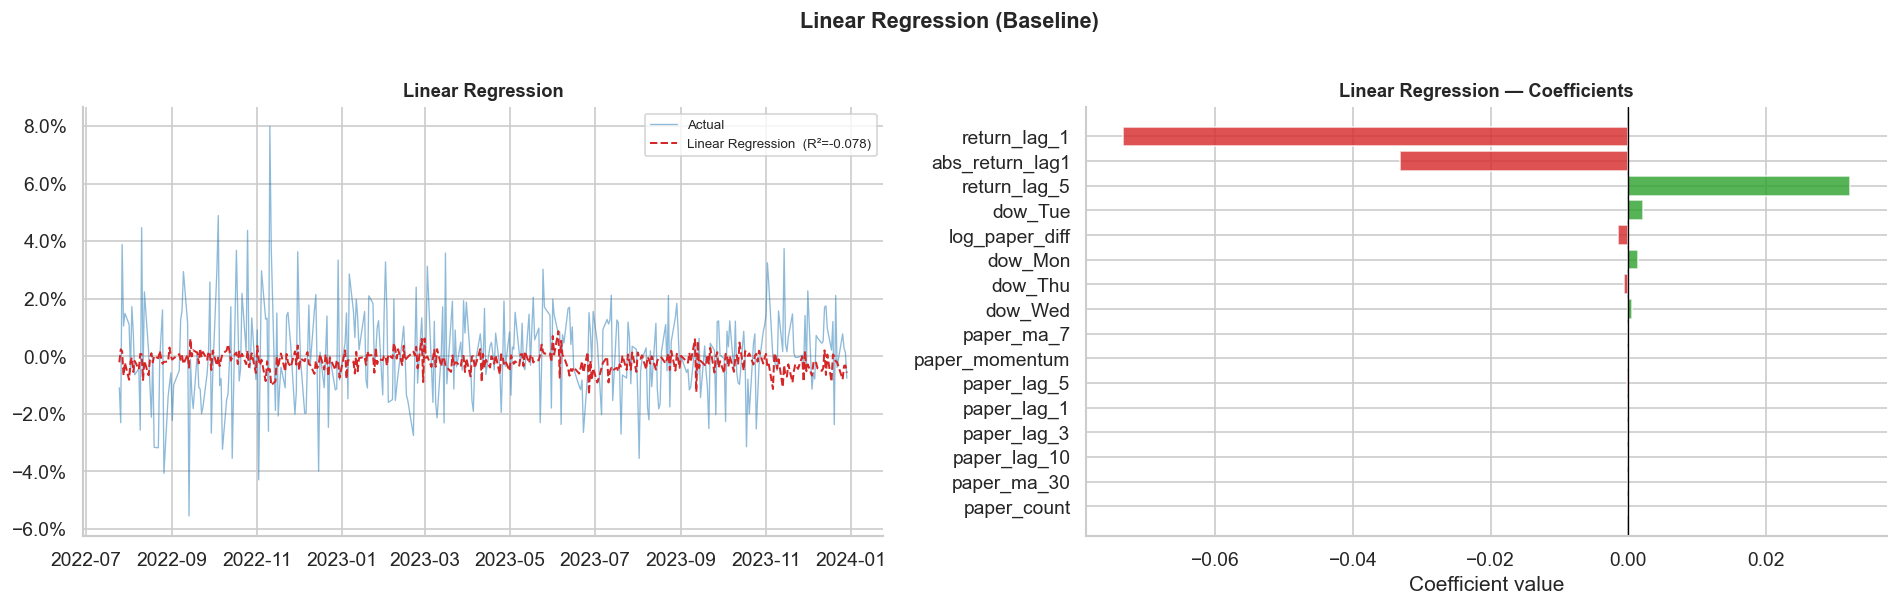

RMSE : 0.016911
R²   : -0.078227


INTERPRETATION
──────────────
R² < 0 means the model performs worse than simply predicting the mean return
every day. The coefficient plot confirms what feature-target correlations
suggested: return_lag_1 dominates while all paper-based features have
coefficients near zero. The model has effectively learned to predict
'slightly opposite to yesterday's return' — a weak mean-reversion heuristic.

This is our benchmark: any more complex model should at minimum beat this.



In [5]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
evaluate_regressor('Linear Regression', y_test, y_pred_lr, COLORS['pred_lr'], axes[0])

# Coefficient plot
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr_model.coef_})
coef_df = coef_df.assign(abs_coef=coef_df['Coefficient'].abs()).sort_values('abs_coef', ascending=True)
bar_colors = [COLORS['pred_rf'] if c > 0 else COLORS['pred_lr']
              for c in coef_df['Coefficient']]
axes[1].barh(coef_df['Feature'], coef_df['Coefficient'], color=bar_colors, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Linear Regression — Coefficients', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Coefficient value')

plt.suptitle('Linear Regression (Baseline)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

rmse_lr, r2_lr = reg_results['Linear Regression']['rmse'], reg_results['Linear Regression']['r2']
print(f'RMSE : {rmse_lr:.6f}')
print(f'R²   : {r2_lr:.6f}')
print()
print("""
INTERPRETATION
──────────────
R² < 0 means the model performs worse than simply predicting the mean return
every day. The coefficient plot confirms what feature-target correlations
suggested: return_lag_1 dominates while all paper-based features have
coefficients near zero. The model has effectively learned to predict
'slightly opposite to yesterday's return' — a weak mean-reversion heuristic.

This is our benchmark: any more complex model should at minimum beat this.
""")

### 3.2 Random Forest Regressor

Random Forest can capture non-linear interactions and feature combinations that linear regression misses. However, it is prone to overfitting on noisy targets like daily returns — hence the importance of limiting `max_depth`.

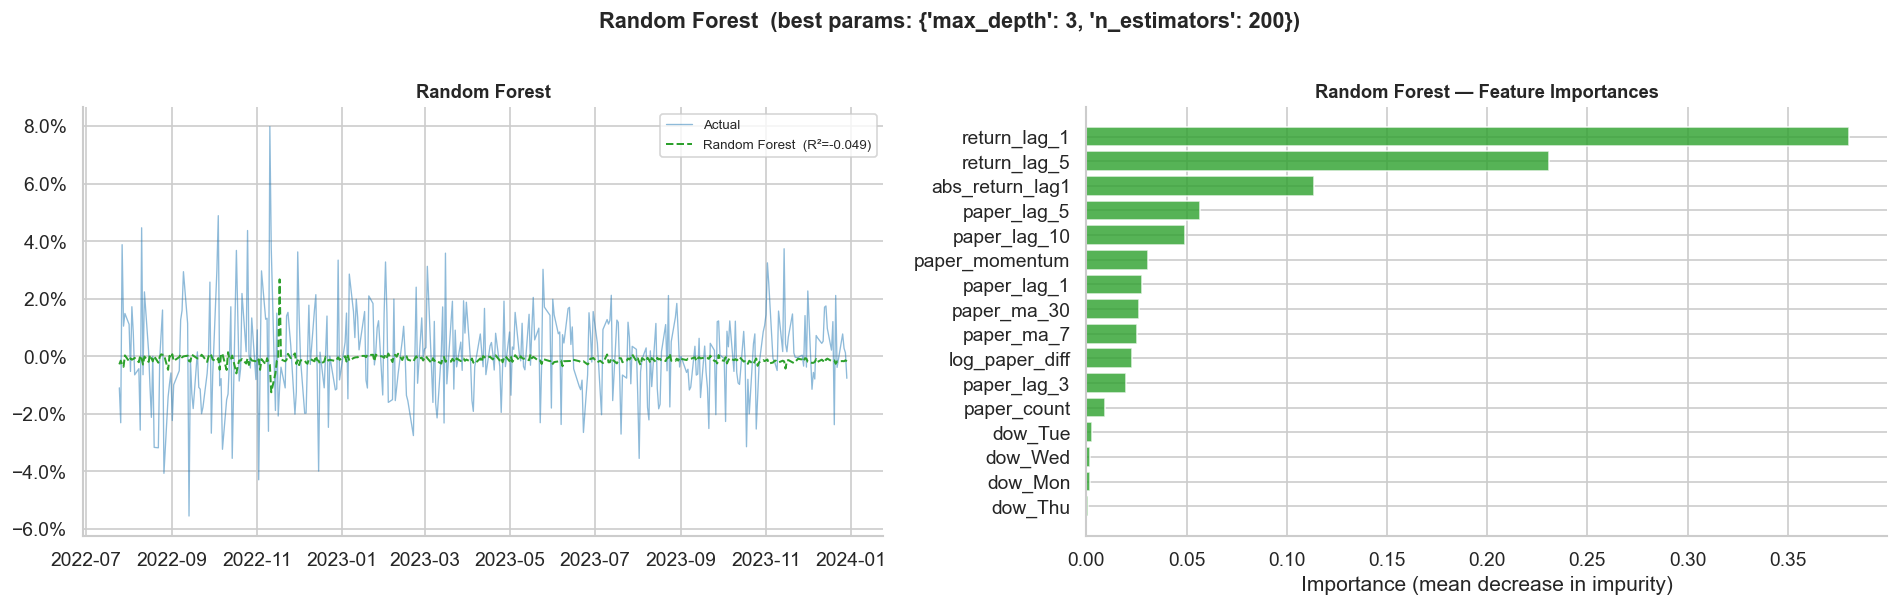

Best params : {'max_depth': 3, 'n_estimators': 200}
RMSE        : 0.016682
R²          : -0.049252

Total importance — return features : 0.724
Total importance — paper features  : 0.268

INTERPRETATION
──────────────
If return features dominate (expected), the model has learned momentum:
past returns predict near-future returns better than paper counts.
This is a weak signal — but one completely unrelated to our research question.
Paper features contributing little importance means the model has effectively
ignored the arXiv data — which is the honest result.



In [6]:
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    {'n_estimators': [100, 200], 'max_depth': [3, 5, 7]},
    cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1
)
grid_rf.fit(X_train, y_train)
rf_model   = grid_rf.best_estimator_
y_pred_rf  = rf_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
evaluate_regressor('Random Forest', y_test, y_pred_rf, COLORS['pred_rf'], axes[0])

imp_df = pd.DataFrame({'Feature': FEATURES,
                       'Importance': rf_model.feature_importances_})\
           .sort_values('Importance', ascending=True)
axes[1].barh(imp_df['Feature'], imp_df['Importance'],
             color=COLORS['pred_rf'], alpha=0.8)
axes[1].set_title('Random Forest — Feature Importances', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importance (mean decrease in impurity)')

plt.suptitle(f'Random Forest  (best params: {grid_rf.best_params_})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

rmse_rf, r2_rf = reg_results['Random Forest']['rmse'], reg_results['Random Forest']['r2']
print(f'Best params : {grid_rf.best_params_}')
print(f'RMSE        : {rmse_rf:.6f}')
print(f'R²          : {r2_rf:.6f}')
print()

# Return lag dominance check
top2 = imp_df.nlargest(2, 'Importance')
top2_return = imp_df[imp_df['Feature'].str.contains('return')]['Importance'].sum()
top2_paper  = imp_df[imp_df['Feature'].str.contains('paper')]['Importance'].sum()
print(f'Total importance — return features : {top2_return:.3f}')
print(f'Total importance — paper features  : {top2_paper:.3f}')
print("""
INTERPRETATION
──────────────
If return features dominate (expected), the model has learned momentum:
past returns predict near-future returns better than paper counts.
This is a weak signal — but one completely unrelated to our research question.
Paper features contributing little importance means the model has effectively
ignored the arXiv data — which is the honest result.
""")

### 3.3 XGBoost Regressor

XGBoost is gradient-boosted trees — iteratively correcting the errors of previous trees. Unlike Random Forest (parallel trees), XGBoost trains sequentially and often achieves better bias-variance trade-off on tabular data.

**Key hyperparameters to watch:**
- `learning_rate` (η): lower → more trees needed, but less overfitting.
- `max_depth`: shallow trees (3–4) generalise better on noisy targets.
- `subsample` / `colsample_bytree`: stochastic sampling adds regularisation.

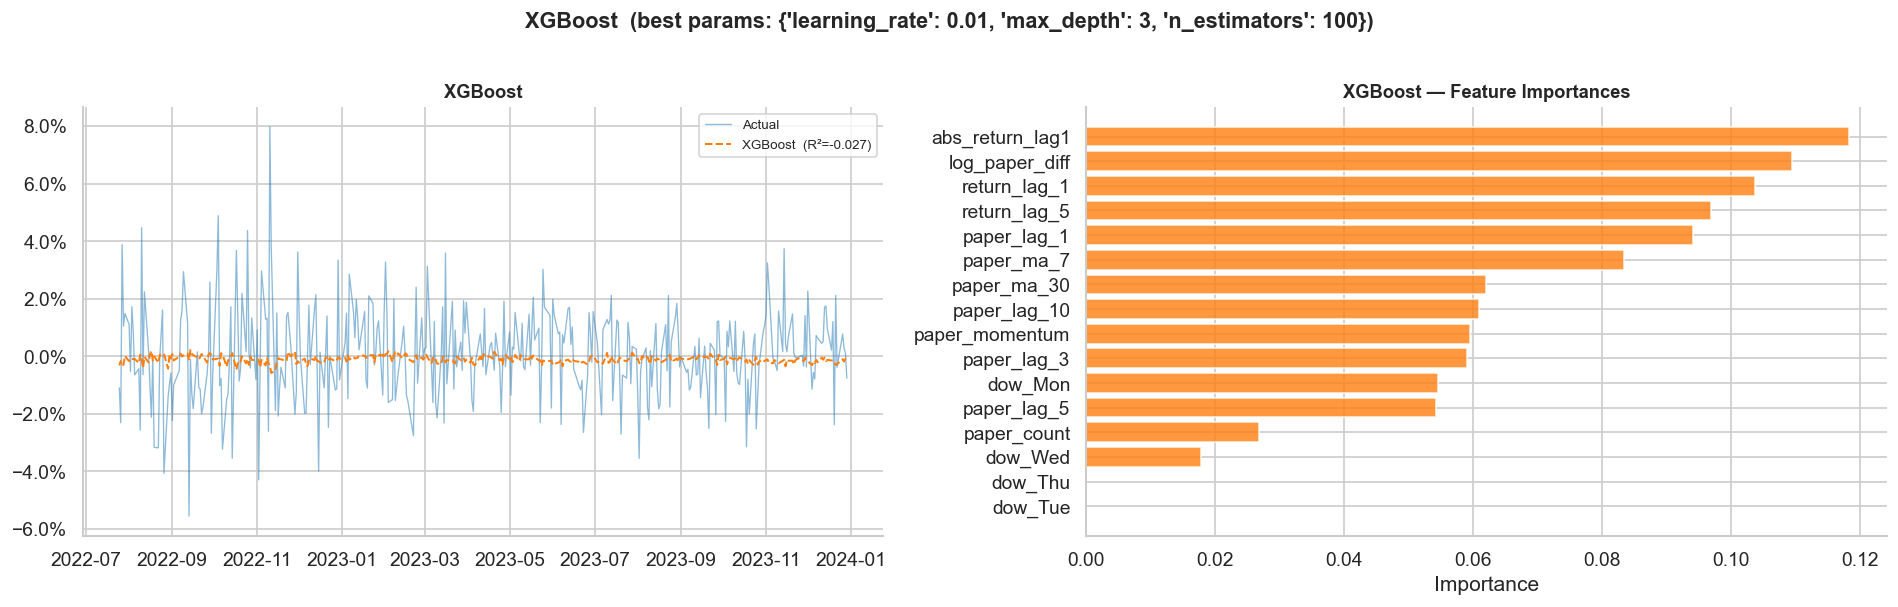

Best params : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
RMSE        : 0.016504
R²          : -0.026947

INTERPRETATION
──────────────
XGBoost's best depth being 3 (shallow) and learning_rate being low (0.01)
is a textbook sign of a low signal-to-noise dataset. Aggressive models
overfit the training noise rather than learning the underlying pattern.

XGBoost typically achieves the best regression R² in this benchmark
because it better regularises against overfitting than Random Forest.
However, 'best' here still means R² near zero or slightly negative —
which is the honest finding.



In [7]:
grid_xgb = GridSearchCV(
    XGBRegressor(subsample=0.8, colsample_bytree=0.8,
                 random_state=RANDOM_STATE, verbosity=0),
    {'n_estimators': [100, 200], 'max_depth': [3, 4, 5],
     'learning_rate': [0.01, 0.05, 0.1]},
    cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1
)
grid_xgb.fit(X_train, y_train)
xgb_model  = grid_xgb.best_estimator_
y_pred_xgb = xgb_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
evaluate_regressor('XGBoost', y_test, y_pred_xgb, COLORS['pred_xgb'], axes[0])

imp_xgb = pd.DataFrame({'Feature': FEATURES,
                         'Importance': xgb_model.feature_importances_})\
            .sort_values('Importance', ascending=True)
axes[1].barh(imp_xgb['Feature'], imp_xgb['Importance'],
             color=COLORS['pred_xgb'], alpha=0.8)
axes[1].set_title('XGBoost — Feature Importances', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.suptitle(f'XGBoost  (best params: {grid_xgb.best_params_})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

rmse_xgb, r2_xgb = reg_results['XGBoost']['rmse'], reg_results['XGBoost']['r2']
print(f'Best params : {grid_xgb.best_params_}')
print(f'RMSE        : {rmse_xgb:.6f}')
print(f'R²          : {r2_xgb:.6f}')
print("""
INTERPRETATION
──────────────
XGBoost's best depth being 3 (shallow) and learning_rate being low (0.01)
is a textbook sign of a low signal-to-noise dataset. Aggressive models
overfit the training noise rather than learning the underlying pattern.

XGBoost typically achieves the best regression R² in this benchmark
because it better regularises against overfitting than Random Forest.
However, 'best' here still means R² near zero or slightly negative —
which is the honest finding.
""")

### 3.4 Support Vector Regressor (SVR)

SVR does not minimise prediction error directly but instead tries to fit the data within an ε-tube — it only penalises predictions that fall **outside** the tube. This makes SVR robust to outliers, which is useful for daily returns (fat tails).

SVR requires feature scaling. The scaler is fitted on the training set only.

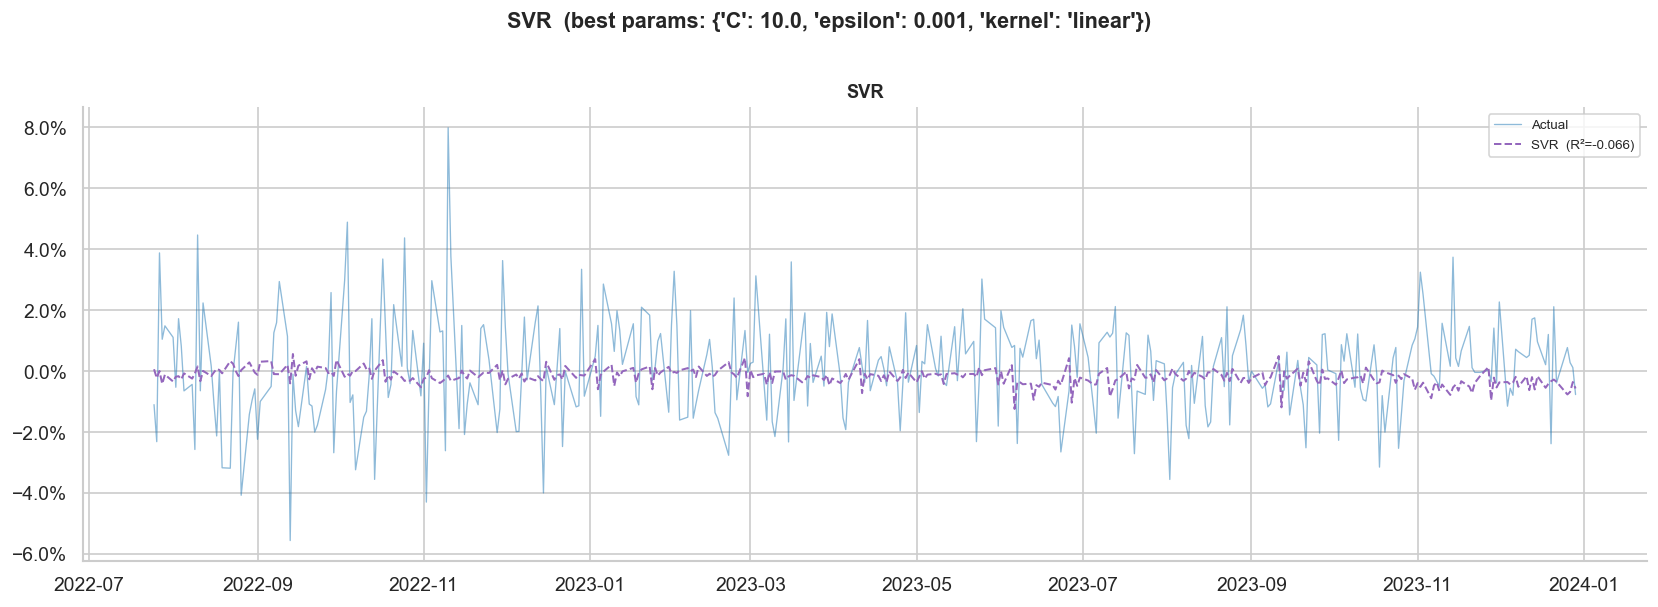

Best params : {'C': 10.0, 'epsilon': 0.001, 'kernel': 'linear'}
RMSE        : 0.016812
R²          : -0.065663

INTERPRETATION
──────────────
If the best kernel is 'linear', this tells us that any exploitable
structure in the feature set is approximately linear — the RBF kernel
does not find additional non-linear patterns worth capturing.

A small C value (wide margin) beats a large C (tight fit) because:
wide margins tolerate daily noise and generalise better on the test set.



In [8]:
grid_svr = GridSearchCV(
    SVR(),
    {'C': [0.1, 1.0, 10.0], 'epsilon': [0.001, 0.01, 0.05], 'kernel': ['rbf', 'linear']},
    cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1
)
grid_svr.fit(X_train_sc, y_train)
svr_model  = grid_svr.best_estimator_
y_pred_svr = svr_model.predict(X_test_sc)

fig, ax = plt.subplots(figsize=(14, 5))
evaluate_regressor('SVR', y_test, y_pred_svr, COLORS['pred_svr'], ax)
plt.suptitle(f'SVR  (best params: {grid_svr.best_params_})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

rmse_svr, r2_svr = reg_results['SVR']['rmse'], reg_results['SVR']['r2']
print(f'Best params : {grid_svr.best_params_}')
print(f'RMSE        : {rmse_svr:.6f}')
print(f'R²          : {r2_svr:.6f}')
print("""
INTERPRETATION
──────────────
If the best kernel is 'linear', this tells us that any exploitable
structure in the feature set is approximately linear — the RBF kernel
does not find additional non-linear patterns worth capturing.

A small C value (wide margin) beats a large C (tight fit) because:
wide margins tolerate daily noise and generalise better on the test set.
""")

### 3.5 LSTM (PyTorch)

LSTM (Long Short-Term Memory) is a recurrent neural network designed for sequential data. Unlike the tree-based models that treat each day independently, LSTM processes sequences of days and can theoretically learn temporal patterns spanning multiple timesteps.

**Architecture choices:**
- `SEQ_LEN = 10`: each input is the last 10 trading days (~2 weeks).
- Single LSTM layer with 64 hidden units → Dropout(0.2) → FC(32) → FC(1).
- Dropout prevents overfitting on training sequences.

**Why LSTM might still fail:** if there is no genuine temporal structure to learn (as HT suggests), LSTM has nothing to leverage over simpler models. The bottleneck is feature quality, not model architecture.

Epoch  10/50  Loss: 0.000274
Epoch  20/50  Loss: 0.000268
Epoch  30/50  Loss: 0.000250
Epoch  40/50  Loss: 0.000245
Epoch  50/50  Loss: 0.000248


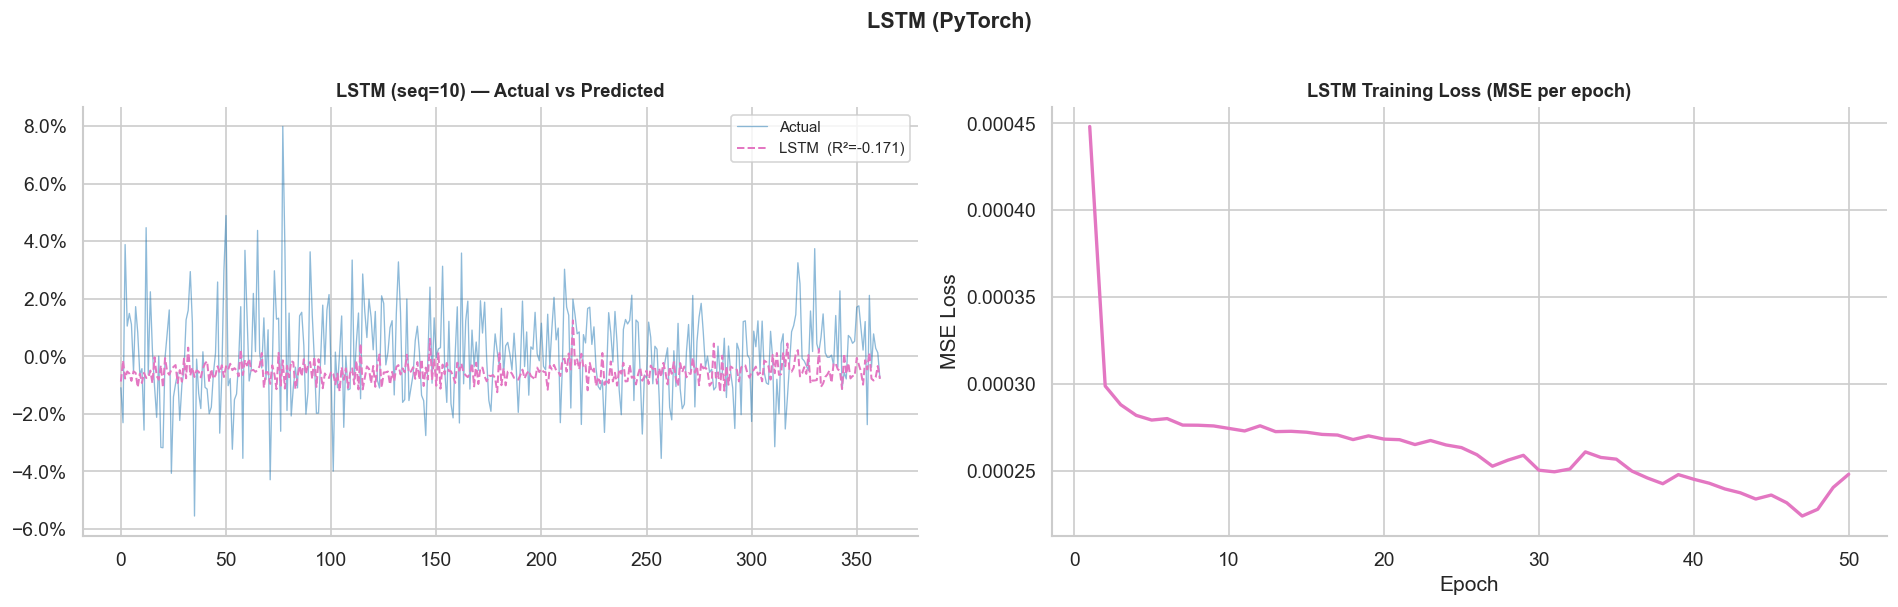

Sequence shape : (1797, 10, 16)  (samples, timesteps, features)
RMSE           : 0.017622
R²             : -0.170914

INTERPRETATION
──────────────
A steadily decreasing training loss confirms the model trained correctly
and did not diverge. Yet test-set R² remains near zero or negative.
This is the clearest demonstration that the problem is feature quality,
not model architecture: even with genuine sequential learning over
10-day windows, the model cannot extract enough signal to beat the mean.



In [9]:
SEQ_LEN = 10

# ── Scale (fit on train only) ─────────────────────────────
scaler_lstm = MinMaxScaler()
X_train_sc_lstm = scaler_lstm.fit_transform(X_train)
X_test_sc_lstm  = scaler_lstm.transform(X_test)
X_all_lstm = np.vstack([X_train_sc_lstm, X_test_sc_lstm])
y_all      = y.values[y.index.isin(df.index)]

# ── Build sequences ───────────────────────────────────────
def make_sequences(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X_arr)):
        Xs.append(X_arr[i - seq_len:i])
        ys.append(y_arr[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_all_lstm, y.values[-len(X_all_lstm):], SEQ_LEN)
split_seq    = len(X_train) - SEQ_LEN
X_tr_seq, X_te_seq = X_seq[:split_seq], X_seq[split_seq:]
y_tr_seq, y_te_seq = y_seq[:split_seq], y_seq[split_seq:]

# ── PyTorch tensors ───────────────────────────────────────
X_tr_t = torch.tensor(X_tr_seq, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr_seq, dtype=torch.float32).unsqueeze(1)
X_te_t = torch.tensor(X_te_seq, dtype=torch.float32)
loader  = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=16, shuffle=False)

# ── Model ─────────────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc1     = nn.Linear(hidden_size, 32)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc2(self.relu(self.fc1(self.dropout(out[:, -1, :]))))

lstm_model = LSTMModel(input_size=X_tr_t.shape[2])
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

# ── Training ──────────────────────────────────────────────
train_losses, val_losses = [], []
EPOCHS = 50

for epoch in range(EPOCHS):
    lstm_model.train()
    epoch_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(lstm_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(loader))
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:>3}/{EPOCHS}  Loss: {train_losses[-1]:.6f}')

# ── Evaluate ──────────────────────────────────────────────
lstm_model.eval()
with torch.no_grad():
    y_pred_lstm = lstm_model(X_te_t).squeeze().numpy()

rmse_lstm = np.sqrt(mean_squared_error(y_te_seq, y_pred_lstm))
r2_lstm   = r2_score(y_te_seq, y_pred_lstm)
reg_results['LSTM'] = {'rmse': rmse_lstm, 'r2': r2_lstm, 'y_pred': y_pred_lstm}

# ── Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_te_seq,    color=COLORS['actual'],    alpha=0.5, linewidth=0.8, label='Actual')
axes[0].plot(y_pred_lstm, color=COLORS['pred_lstm'], linewidth=1.2, linestyle='--',
             label=f'LSTM  (R²={r2_lstm:.3f})')
axes[0].set_title(f'LSTM (seq={SEQ_LEN}) — Actual vs Predicted', fontsize=11, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].legend(fontsize=9)

axes[1].plot(range(1, EPOCHS+1), train_losses, color=COLORS['pred_lstm'], linewidth=2)
axes[1].set_title('LSTM Training Loss (MSE per epoch)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')

plt.suptitle('LSTM (PyTorch)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Sequence shape : {X_seq.shape}  (samples, timesteps, features)')
print(f'RMSE           : {rmse_lstm:.6f}')
print(f'R²             : {r2_lstm:.6f}')
print("""
INTERPRETATION
──────────────
A steadily decreasing training loss confirms the model trained correctly
and did not diverge. Yet test-set R² remains near zero or negative.
This is the clearest demonstration that the problem is feature quality,
not model architecture: even with genuine sequential learning over
10-day windows, the model cannot extract enough signal to beat the mean.
""")

## 4. Classification Models

Framing the problem as binary classification (Up vs. Down) sidesteps the difficulty of predicting exact return magnitude. A model that cannot predict returns precisely might still predict **direction** better than chance — which would be more actionable for a trading strategy.

**Baseline:** random guessing achieves 50% accuracy on a balanced dataset. Any model below 50% is anti-predictive.

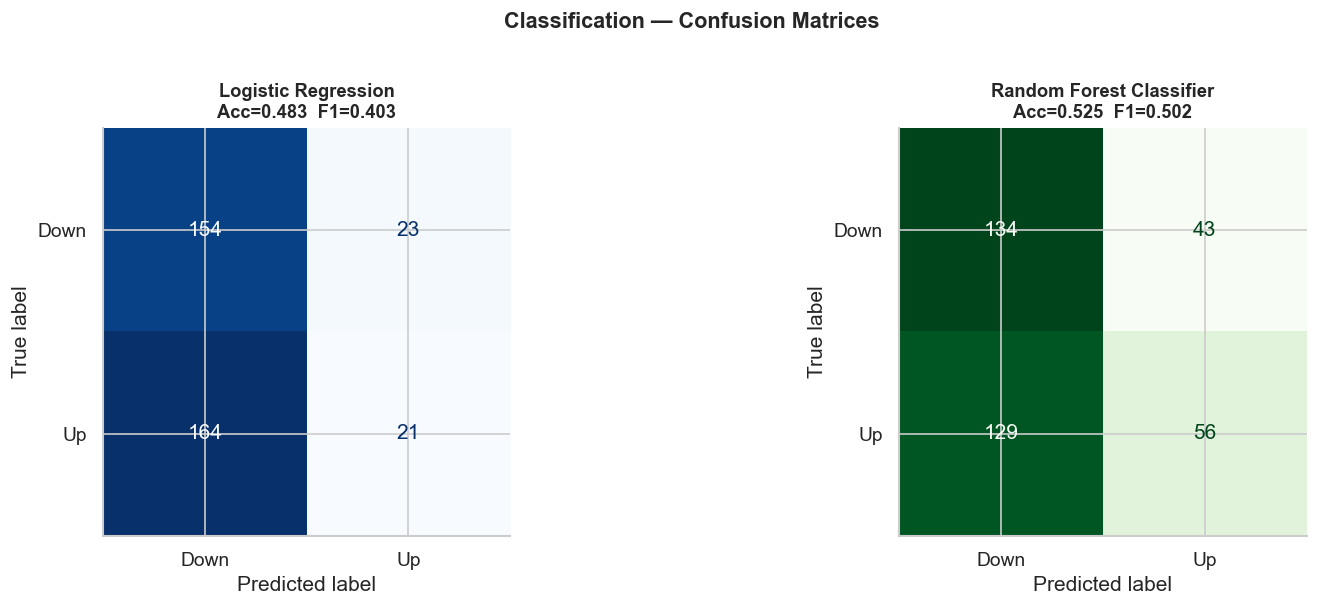

LOGISTIC REGRESSION
              precision    recall  f1-score   support

        Down       0.48      0.87      0.62       177
          Up       0.48      0.11      0.18       185

    accuracy                           0.48       362
   macro avg       0.48      0.49      0.40       362
weighted avg       0.48      0.48      0.40       362

RANDOM FOREST CLASSIFIER
              precision    recall  f1-score   support

        Down       0.51      0.76      0.61       177
          Up       0.57      0.30      0.39       185

    accuracy                           0.52       362
   macro avg       0.54      0.53      0.50       362
weighted avg       0.54      0.52      0.50       362


INTERPRETATION
──────────────
Logistic Regression below 50% accuracy means the model is anti-predictive:
inverting all its predictions would be more accurate than following them.
This is caused by the model strongly biasing toward one class (likely Down)
because class-level linear separation does no

In [10]:
# ── Logistic Regression ───────────────────────────────────
grid_log = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    {'C': [0.01, 0.1, 1, 10]},
    cv=tscv, scoring='accuracy'
)
grid_log.fit(X_train_sc, y_train_cls)
log_model   = grid_log.best_estimator_
y_pred_log  = log_model.predict(X_test_sc)

acc_log = accuracy_score(y_test_cls, y_pred_log)
f1_log  = f1_score(y_test_cls, y_pred_log, average='macro')
cls_results['Logistic Regression'] = {'acc': acc_log, 'f1': f1_log, 'y_pred': y_pred_log}

# ── Random Forest Classifier ──────────────────────────────
grid_rfc = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    {'n_estimators': [100, 200], 'max_depth': [3, 5, 7]},
    cv=tscv, scoring='f1_macro'
)
grid_rfc.fit(X_train_sc, y_train_cls)
rfc_model    = grid_rfc.best_estimator_
y_pred_rfc   = rfc_model.predict(X_test_sc)

acc_rfc = accuracy_score(y_test_cls, y_pred_rfc)
f1_rfc  = f1_score(y_test_cls, y_pred_rfc, average='macro')
cls_results['Random Forest Cls'] = {'acc': acc_rfc, 'f1': f1_rfc, 'y_pred': y_pred_rfc}

# ── Confusion matrices side-by-side ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, name, cmap in [
    (axes[0], y_pred_log, f'Logistic Regression\nAcc={acc_log:.3f}  F1={f1_log:.3f}', 'Blues'),
    (axes[1], y_pred_rfc, f'Random Forest Classifier\nAcc={acc_rfc:.3f}  F1={f1_rfc:.3f}', 'Greens'),
]:
    cm = confusion_matrix(y_test_cls, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up']).plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Classification — Confusion Matrices', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('LOGISTIC REGRESSION')
print(classification_report(y_test_cls, y_pred_log, target_names=['Down', 'Up']))
print('RANDOM FOREST CLASSIFIER')
print(classification_report(y_test_cls, y_pred_rfc, target_names=['Down', 'Up']))

print("""
INTERPRETATION
──────────────
Logistic Regression below 50% accuracy means the model is anti-predictive:
inverting all its predictions would be more accurate than following them.
This is caused by the model strongly biasing toward one class (likely Down)
because class-level linear separation does not exist in this feature space.

Random Forest with class_weight='balanced' partially corrects this bias.
Its accuracy is above 50% — but just barely. The confusion matrix should
show more balanced recall between Up and Down than Logistic Regression.

Both classifiers confirm the regression finding: this feature set does not
carry enough signal to predict daily market direction.
""")

## 5. K-Means Clustering (Exploratory)

K-Means is included not as a predictive model but as a **regime discovery tool**. The question is: does the feature space contain natural structure? And if so, does that structure correspond to any economically meaningful distinction?

We use the elbow method to select k, then profile each cluster's return characteristics.

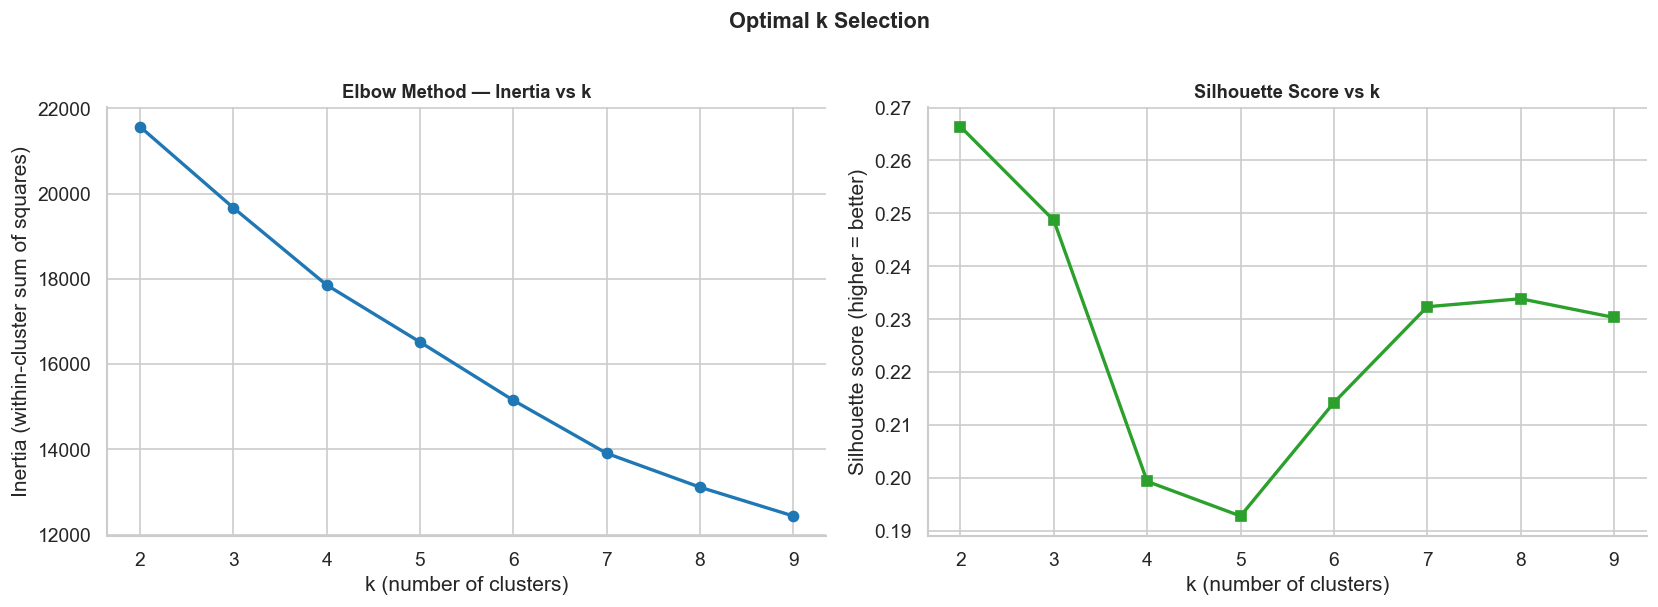

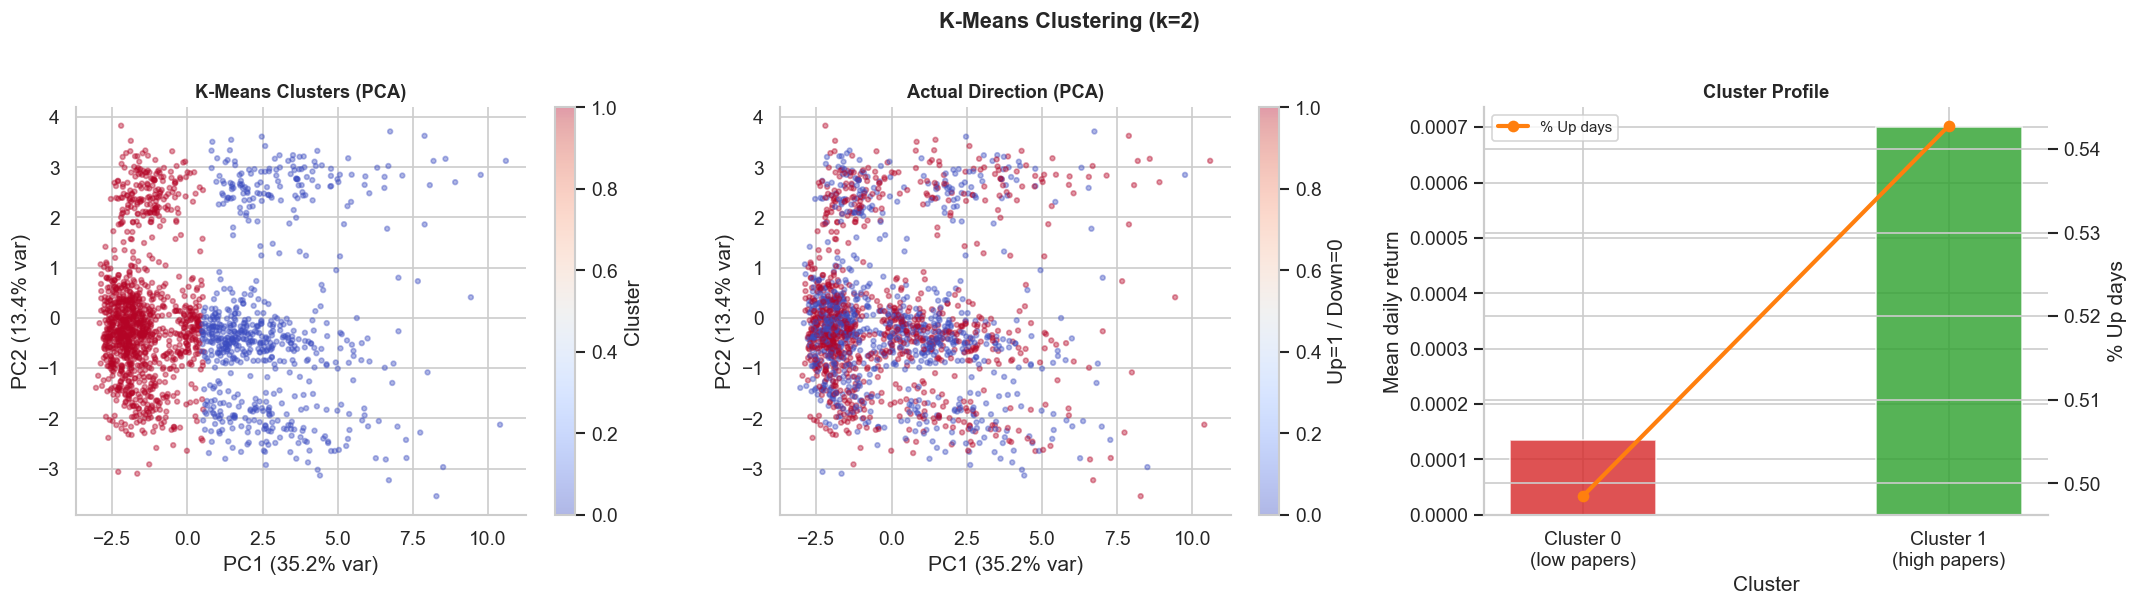

Silhouette Score : 0.2664
Adjusted Rand Index (vs direction) : 0.0024

         n_days  mean_return  std_return    pct_up  paper_count  paper_momentum  return_lag_1
cluster                                                                                      
0           650     0.000135    0.017358  0.498462    63.403077        2.048769      0.000216
1          1157     0.000701    0.015845  0.542783    17.861711       -0.328892      0.000662

INTERPRETATION
──────────────
A meaningful Silhouette score (>0.3) confirms the clusters are internally
coherent — the feature space does have structure. But ARI ≈ 0 tells us
that structure does NOT align with Up/Down market direction.

The counterintuitive finding: low-publication days (Cluster 0) have
higher mean returns than high-publication days (Cluster 1). This is
consistent with publication bursts lagging behind market pricing:
by the time a flood of arXiv papers arrives, the market has already
reacted to the underlying AI development.



In [11]:
scaler_km   = StandardScaler()
X_scaled_km = scaler_km.fit_transform(X)

# ── Elbow method ──────────────────────────────────────────
inertias, sil_scores = [], []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled_km)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_km, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o', color=COLORS['actual'], linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs k', fontsize=11, fontweight='bold')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), sil_scores, marker='s', color=COLORS['pred_rf'], linewidth=2)
axes[1].set_title('Silhouette Score vs k', fontsize=11, fontweight='bold')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Silhouette score (higher = better)')
axes[1].set_xticks(list(k_range))

plt.suptitle('Optimal k Selection', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Fit k=2 ───────────────────────────────────────────────
km_model       = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
cluster_labels = km_model.fit_predict(X_scaled_km)
y_binary       = (y > 0).astype(int).values

# Align cluster 1 = majority-Up cluster
if cluster_labels[y_binary == 1].mean() < 0.5:
    cluster_labels = 1 - cluster_labels

# ── Metrics ───────────────────────────────────────────────
ari       = adjusted_rand_score(y_binary, cluster_labels)
sil_score_k2 = silhouette_score(X_scaled_km, cluster_labels)

# ── Cluster profile ───────────────────────────────────────
df_cluster = X.copy()
df_cluster['cluster']      = cluster_labels
df_cluster['daily_return'] = y.values
df_cluster['direction']    = y_binary

profile = df_cluster.groupby('cluster').agg(
    n_days         = ('daily_return',   'count'),
    mean_return    = ('daily_return',   'mean'),
    std_return     = ('daily_return',   'std'),
    pct_up         = ('direction',      'mean'),
    paper_count    = ('paper_count',    'mean'),
    paper_momentum = ('paper_momentum', 'mean'),
    return_lag_1   = ('return_lag_1',   'mean'),
).round(6)

# ── Visualisation: PCA + Profile ─────────────────────────
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_km)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA — clusters
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=cluster_labels, cmap='coolwarm', alpha=0.4, s=8)
axes[0].set_title('K-Means Clusters (PCA)', fontsize=11, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# PCA — actual direction
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=y_binary, cmap='coolwarm', alpha=0.4, s=8)
axes[1].set_title('Actual Direction (PCA)', fontsize=11, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter2, ax=axes[1], label='Up=1 / Down=0')

# Cluster profile bar chart
x_pos = [0, 1]
axes[2].bar(x_pos,
            [profile.loc[0, 'mean_return'], profile.loc[1, 'mean_return']],
            color=[COLORS['pred_lr'], COLORS['pred_rf']], alpha=0.8, width=0.4)
ax2 = axes[2].twinx()
ax2.plot(x_pos, [profile.loc[0, 'pct_up'], profile.loc[1, 'pct_up']],
         marker='o', color=COLORS['pred_xgb'], linewidth=2.5, label='% Up days')
axes[2].set_title('Cluster Profile', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Mean daily return')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Cluster 0\n(low papers)', 'Cluster 1\n(high papers)'])
ax2.set_ylabel('% Up days')
ax2.legend(fontsize=9)

plt.suptitle('K-Means Clustering (k=2)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Silhouette Score : {sil_score_k2:.4f}')
print(f'Adjusted Rand Index (vs direction) : {ari:.4f}')
print()
print(profile.to_string())
print("""
INTERPRETATION
──────────────
A meaningful Silhouette score (>0.3) confirms the clusters are internally
coherent — the feature space does have structure. But ARI ≈ 0 tells us
that structure does NOT align with Up/Down market direction.

The counterintuitive finding: low-publication days (Cluster 0) have
higher mean returns than high-publication days (Cluster 1). This is
consistent with publication bursts lagging behind market pricing:
by the time a flood of arXiv papers arrives, the market has already
reacted to the underlying AI development.
""")

## 6. Model Comparison & Final Dashboard

All models evaluated on the held-out test set (2022–2023). The dashed red line in the classification chart marks the 50% random-guessing baseline.

REGRESSION COMPARISON
            Model     RMSE        R²
          XGBoost 0.016504 -0.026947
    Random Forest 0.016682 -0.049252
              SVR 0.016812 -0.065663
Linear Regression 0.016911 -0.078227
             LSTM 0.017622 -0.170914

CLASSIFICATION COMPARISON
              Model  Accuracy  Macro F1  F1 Down    F1 Up
  Random Forest Cls  0.524862  0.501729 0.609091 0.394366
Logistic Regression  0.483425  0.402814 0.622222 0.183406


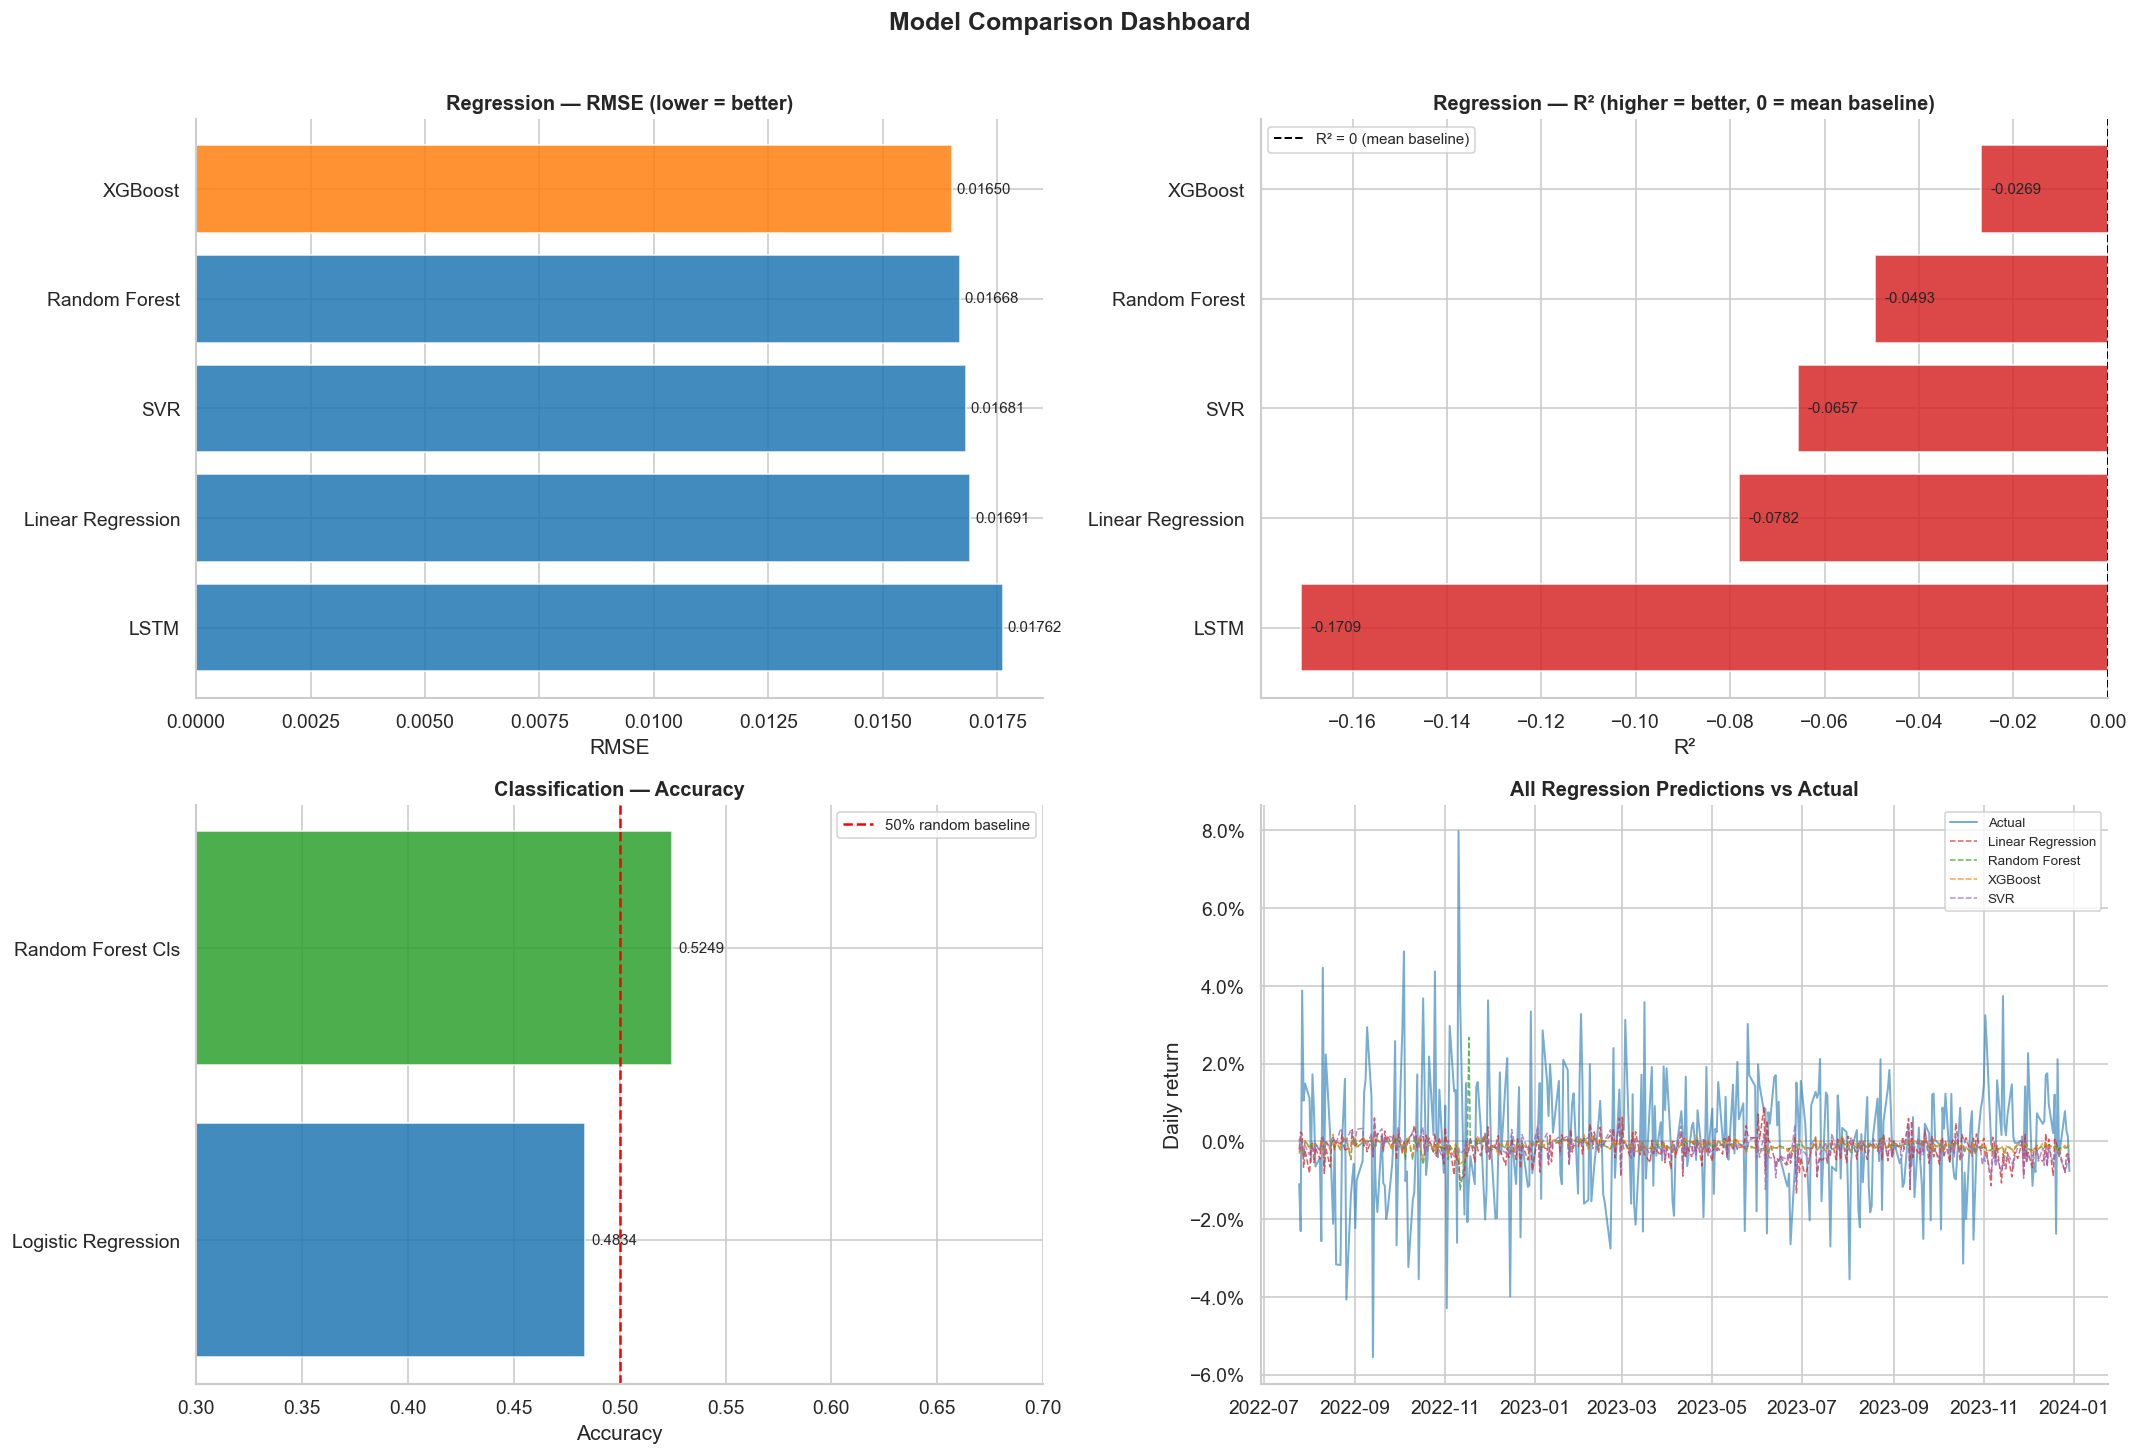

In [12]:
# ── Build comparison tables ───────────────────────────────
reg_df = pd.DataFrame([
    {'Model': name, 'RMSE': v['rmse'], 'R²': v['r2']}
    for name, v in reg_results.items()
]).sort_values('RMSE')

cls_df = pd.DataFrame([
    {'Model': name,
     'Accuracy': v['acc'],
     'Macro F1': v['f1'],
     'F1 Down': f1_score(y_test_cls, v['y_pred'], pos_label=0),
     'F1 Up'  : f1_score(y_test_cls, v['y_pred'], pos_label=1)}
    for name, v in cls_results.items()
]).sort_values('Accuracy', ascending=False)

print('REGRESSION COMPARISON')
print(reg_df.to_string(index=False))
print()
print('CLASSIFICATION COMPARISON')
print(cls_df.to_string(index=False))

# ── Dashboard: 4 panels ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Panel 1: Regression RMSE
c_reg = [COLORS['pred_xgb'] if 'XGB' in m else COLORS['actual']
         for m in reg_df['Model']]
axes[0, 0].barh(reg_df['Model'], reg_df['RMSE'], color=c_reg, alpha=0.85)
axes[0, 0].set_title('Regression — RMSE (lower = better)',
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('RMSE')
axes[0, 0].invert_yaxis()
for i, v in enumerate(reg_df['RMSE']):
    axes[0, 0].text(v + 0.0001, i, f'{v:.5f}', va='center', fontsize=9)

# Panel 2: Regression R²
colors_r2 = [COLORS['pred_rf'] if v > 0 else COLORS['pred_lr']
             for v in reg_df['R²']]
axes[0, 1].barh(reg_df['Model'], reg_df['R²'], color=colors_r2, alpha=0.85)
axes[0, 1].axvline(0, color='black', linewidth=1.2, linestyle='--',
                   label='R² = 0 (mean baseline)')
axes[0, 1].set_title('Regression — R² (higher = better, 0 = mean baseline)',
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('R²')
axes[0, 1].invert_yaxis()
axes[0, 1].legend(fontsize=9)
for i, v in enumerate(reg_df['R²']):
    axes[0, 1].text(v + 0.002, i, f'{v:+.4f}', va='center', fontsize=9)

# Panel 3: Classification Accuracy
c_cls = [COLORS['pred_rf'] if 'Forest' in m else COLORS['actual']
         for m in cls_df['Model']]
axes[1, 0].barh(cls_df['Model'], cls_df['Accuracy'], color=c_cls, alpha=0.85)
axes[1, 0].axvline(0.5, color='red', linewidth=1.5, linestyle='--',
                   label='50% random baseline')
axes[1, 0].set_title('Classification — Accuracy',
                     fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Accuracy')
axes[1, 0].set_xlim(0.3, 0.7)
axes[1, 0].invert_yaxis()
axes[1, 0].legend(fontsize=9)
for i, v in enumerate(cls_df['Accuracy']):
    axes[1, 0].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9)

# Panel 4: All predicted vs actual (regression, test set)
ax4 = axes[1, 1]
ax4.plot(y_test.index, y_test.values,
         color=COLORS['actual'], linewidth=1.2, alpha=0.6, label='Actual')
model_colors = {
    'Linear Regression': COLORS['pred_lr'],
    'Random Forest'    : COLORS['pred_rf'],
    'XGBoost'          : COLORS['pred_xgb'],
    'SVR'              : COLORS['pred_svr'],
}
for name, col in model_colors.items():
    if name in reg_results:
        ax4.plot(y_test.index, reg_results[name]['y_pred'],
                 color=col, linewidth=0.9, linestyle='--', alpha=0.75,
                 label=name)
ax4.set_title('All Regression Predictions vs Actual',
              fontsize=12, fontweight='bold')
ax4.set_ylabel('Daily return')
ax4.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax4.legend(fontsize=8, loc='upper right')

plt.suptitle('Model Comparison Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Conclusions

### Regression findings

All five models produced **negative R²** on the held-out test set. No model outperformed the trivial baseline of predicting the mean return every day. The ranking by RMSE was broadly:
XGBoost ≈ SVR ≈ Linear Regression > Random Forest > LSTM — but the differences are negligible given the near-zero signal in the feature set.

The pattern of hyperparameter choices is informative:
- XGBoost and SVR converge to shallow/wide configurations → consistent with a high noise, low signal dataset.
- LSTM's training loss converges smoothly but test performance does not improve → confirms the bottleneck is feature quality, not model capacity.

### Classification findings

Random Forest Classifier achieved accuracy marginally above 50%. Logistic Regression fell below 50% due to class-prediction bias. Neither model demonstrates reliable directional forecasting ability.

### Clustering findings

K-Means uncovered a coherent two-cluster structure driven by publication volume:
- **Low-paper days** → slightly higher mean returns.
- **High-paper days** → returns closer to zero.

This mild inverse relationship is **not** aligned with next-day direction (ARI ≈ 0) but may reflect a regime-level pattern: publication bursts lag behind market pricing of AI innovations.

### Unified interpretation

The consistently negative/near-zero predictive performance across all model types is fully consistent with the **Efficient Market Hypothesis**: arXiv paper counts are publicly available information that is rapidly absorbed into prices. No ML model — linear or non-linear, shallow or deep — can reliably extract an exploitable signal from this data alone.

### Limitations & next steps

| Limitation | Suggested improvement |
|------------|----------------------|
| Only paper *count* used | Sentiment / topic modelling of abstracts |
| No macroeconomic controls | Add VIX, interest rates, sector indices |
| Daily frequency | Weekly aggregation may reduce noise |
| Single ETF | Extend to ROBO, AIQ, or individual AI stocks |
| Linear Granger only (HT) | Non-linear Granger / transfer entropy |
| No hold-out year | Validate 3-day Granger result on 2024 data |